In [1]:
# I first import the main libraries and load my household electricity dataset.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# I use a raw string here because the dataset path is from Windows.
file_path = r"C:\Users\DELL\Downloads\individual+household+electric+power+consumption\household_power_consumption.txt"

# I check whether the file path exists before loading, so I can catch path errors early.
path_check = Path(file_path)

print("File exists:", path_check.exists())
print("Dataset path:", file_path)

# The dataset uses semicolons, and missing values are marked as '?'.
df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("Dataset loaded successfully.")
print("Shape of the dataset:", df.shape)

df.head()

File exists: True
Dataset path: C:\Users\DELL\Downloads\individual+household+electric+power+consumption\household_power_consumption.txt
Dataset loaded successfully.
Shape of the dataset: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [2]:
# I inspect the dataset structure before doing any cleaning or modelling.

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values in each column:")
missing_values = df.isna().sum()
print(missing_values)

print("\nMissing value percentage in each column:")
missing_percent = (df.isna().mean() * 100).round(3)
print(missing_percent)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nBasic numerical summary:")
display(df.describe())

Dataset shape: (2075259, 9)

Column names:
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Data types:
Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

Missing values in each column:
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing value percentage in each column:
Date                     0.000
Time                     0.000
Global_active_power      1.252
Global_reactive_power   

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


In [3]:
# I combine Date and Time into one datetime column so the dataset can be treated as a time series.

df["datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

print("Rows with invalid datetime values:", df["datetime"].isna().sum())

# I set datetime as the index because forecasting depends on the correct time order.
df = df.drop(columns=["Date", "Time"])
df = df.set_index("datetime")
df = df.sort_index()

print("\nTime range:")
print("Start:", df.index.min())
print("End:", df.index.max())

print("\nDataset shape after datetime conversion:", df.shape)

# I check the expected minute-level frequency.
time_diffs = df.index.to_series().diff().value_counts().head(10)

print("\nMost common time gaps between records:")
print(time_diffs)

print("\nFirst five rows after datetime conversion:")
display(df.head())

Rows with invalid datetime values: 0

Time range:
Start: 2006-12-16 17:24:00
End: 2010-11-26 21:02:00

Dataset shape after datetime conversion: (2075259, 7)

Most common time gaps between records:
datetime
0 days 00:01:00    2075258
Name: count, dtype: int64

First five rows after datetime conversion:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
# I convert the minute-level readings into hourly averages to reduce noise and make the forecasting task manageable.

hourly_df = df.resample("h").mean()

print("Original minute-level shape:", df.shape)
print("Hourly dataset shape:", hourly_df.shape)

print("\nTime range after hourly resampling:")
print("Start:", hourly_df.index.min())
print("End:", hourly_df.index.max())

print("\nMissing values after hourly resampling:")
print(hourly_df.isna().sum())

print("\nMissing value percentage after hourly resampling:")
print((hourly_df.isna().mean() * 100).round(3))

print("\nHourly dataset preview:")
display(hourly_df.head())

print("\nHourly numerical summary:")
display(hourly_df.describe())

Original minute-level shape: (2075259, 7)
Hourly dataset shape: (34589, 7)

Time range after hourly resampling:
Start: 2006-12-16 17:00:00
End: 2010-11-26 21:00:00

Missing values after hourly resampling:
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

Missing value percentage after hourly resampling:
Global_active_power      1.217
Global_reactive_power    1.217
Voltage                  1.217
Global_intensity         1.217
Sub_metering_1           1.217
Sub_metering_2           1.217
Sub_metering_3           1.217
dtype: float64

Hourly dataset preview:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667



Hourly numerical summary:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000,34168.000000
mean,1.091728,0.123727,240.839393,4.628238,1.121631,1.298566,6.458882
std,0.897619,0.066851,3.001093,3.757797,3.538046,4.192874,7.351219
min,0.124000,0.000000,225.834500,0.503333,0.000000,0.000000,0.000000
25%,0.341925,0.078000,239.180667,1.513333,0.000000,0.000000,0.650000
50%,0.802850,0.106917,240.977833,3.423333,0.000000,0.333333,1.650000
75%,1.579342,0.149433,242.695000,6.606667,0.000000,0.650000,14.216667
max,6.560533,0.774333,251.902000,28.383333,48.366667,46.433333,21.550000


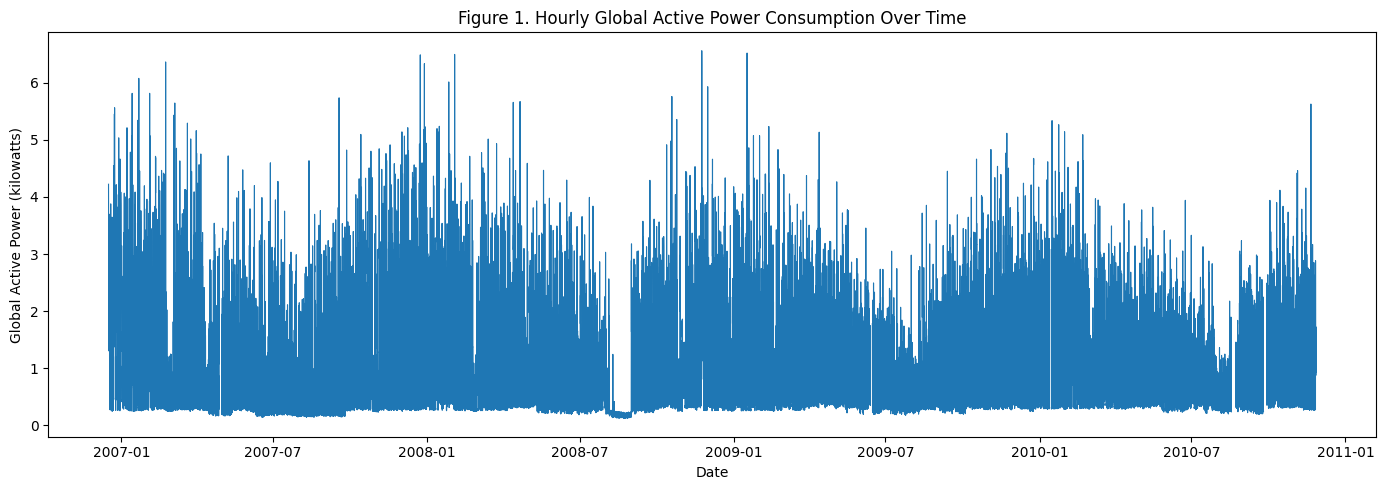

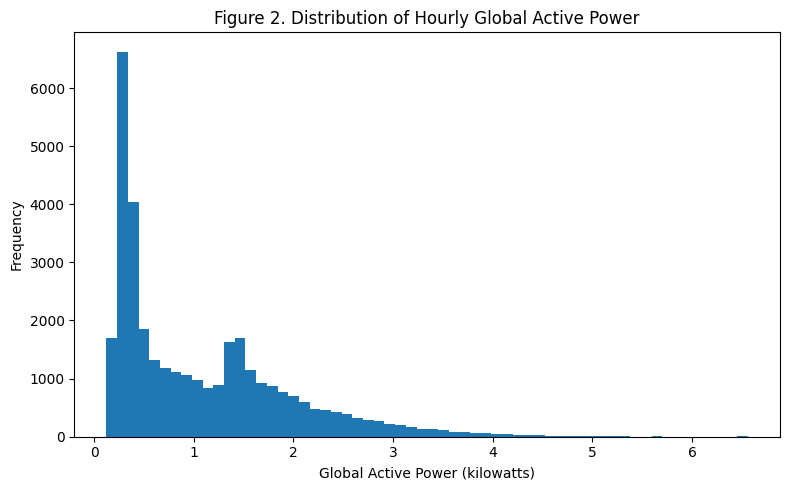

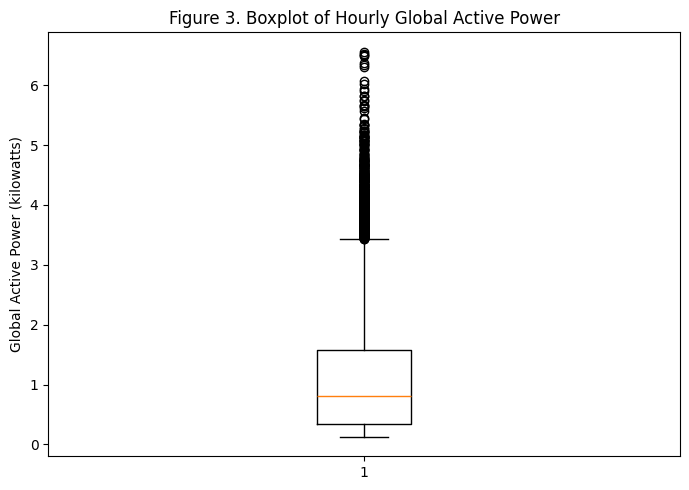

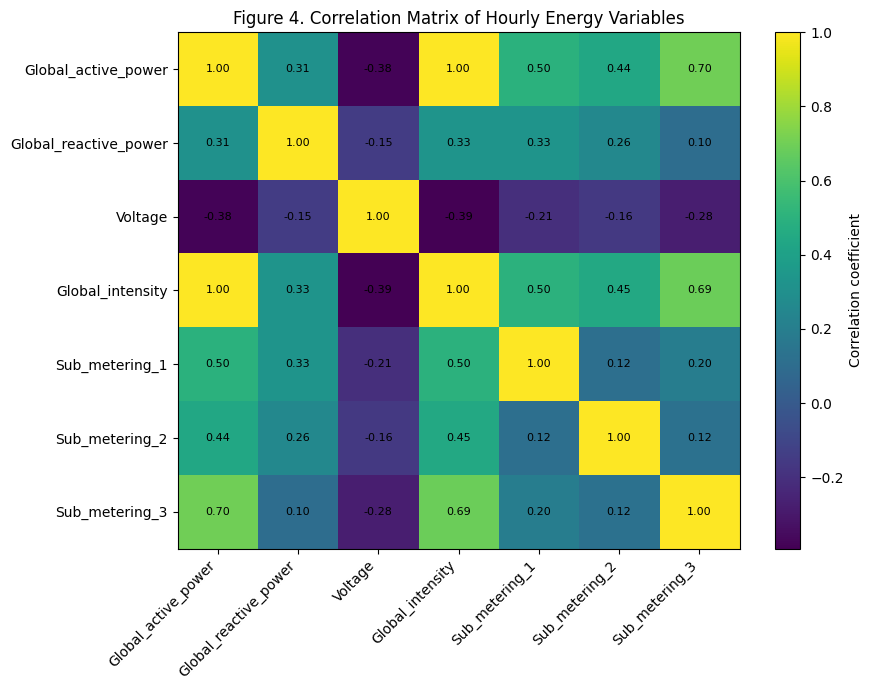

EDA figures saved in: energy_forecasting_figures
Files created:
['figure_1_hourly_global_active_power_over_time.png', 'figure_2_distribution_global_active_power.png', 'figure_3_boxplot_global_active_power.png', 'figure_4_correlation_matrix_hourly_variables.png']


In [5]:
# I create the first EDA figures to understand the hourly energy pattern before cleaning.

import os

# I create a folder to save figures for my report.
fig_dir = "energy_forecasting_figures"
os.makedirs(fig_dir, exist_ok=True)

def save_figure(filename):
    # I use this small helper so every figure is saved consistently.
    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, filename), dpi=300, bbox_inches="tight")
    plt.show()

# Figure 1: Hourly global active power over the full period
plt.figure(figsize=(14, 5))
plt.plot(hourly_df.index, hourly_df["Global_active_power"], linewidth=0.8)
plt.title("Figure 1. Hourly Global Active Power Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kilowatts)")
save_figure("figure_1_hourly_global_active_power_over_time.png")

# Figure 2: Distribution of global active power
plt.figure(figsize=(8, 5))
plt.hist(hourly_df["Global_active_power"].dropna(), bins=60)
plt.title("Figure 2. Distribution of Hourly Global Active Power")
plt.xlabel("Global Active Power (kilowatts)")
plt.ylabel("Frequency")
save_figure("figure_2_distribution_global_active_power.png")

# Figure 3: Boxplot to show possible outliers in the target variable
plt.figure(figsize=(7, 5))
plt.boxplot(hourly_df["Global_active_power"].dropna(), vert=True)
plt.title("Figure 3. Boxplot of Hourly Global Active Power")
plt.ylabel("Global Active Power (kilowatts)")
save_figure("figure_3_boxplot_global_active_power.png")

# Figure 4: Correlation heatmap using matplotlib
corr_matrix = hourly_df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar(label="Correlation coefficient")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Figure 4. Correlation Matrix of Hourly Energy Variables")

# I add the correlation values into the heatmap for easier interpretation.
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

save_figure("figure_4_correlation_matrix_hourly_variables.png")

print("EDA figures saved in:", fig_dir)
print("Files created:")
print(os.listdir(fig_dir))

In [6]:
# I treat missing values using time-based interpolation because this is a continuous hourly time series.

clean_df = hourly_df.copy()

print("Missing values before interpolation:")
print(clean_df.isna().sum())

# I use time interpolation because neighbouring hours usually give a reasonable estimate in electricity data.
clean_df = clean_df.interpolate(method="time")

# I also apply forward and backward filling as a safety step for any edge missing values.
clean_df = clean_df.ffill().bfill()

print("\nMissing values after interpolation:")
print(clean_df.isna().sum())

print("\nCleaned hourly dataset shape:", clean_df.shape)

print("\nPreview after missing-value treatment:")
display(clean_df.head())

# I keep this summary for the report's preprocessing section.
missing_summary = pd.DataFrame({
    "Missing before": hourly_df.isna().sum(),
    "Missing after": clean_df.isna().sum(),
    "Missing percentage before": (hourly_df.isna().mean() * 100).round(3),
    "Missing percentage after": (clean_df.isna().mean() * 100).round(3)
})

display(missing_summary)

Missing values before interpolation:
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

Missing values after interpolation:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Cleaned hourly dataset shape: (34589, 7)

Preview after missing-value treatment:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


,Missing before,Missing after,Missing percentage before,Missing percentage after
Global_active_power,421,0,1.217,0.0
Global_reactive_power,421,0,1.217,0.0
Voltage,421,0,1.217,0.0
Global_intensity,421,0,1.217,0.0
Sub_metering_1,421,0,1.217,0.0
Sub_metering_2,421,0,1.217,0.0
Sub_metering_3,421,0,1.217,0.0


Target variable: Global_active_power
Q1: 0.3434
Q3: 1.5782
IQR: 1.2348
Lower bound: -1.5088
Upper bound: 3.4304
Number of outliers detected: 736
Outlier percentage: 2.128 %

Before capping:
count    34589.000000
mean         1.092488
std          0.895746
min          0.124000
25%          0.343433
50%          0.806833
75%          1.578233
max          6.560533
Name: Global_active_power, dtype: float64

After capping:
count    34589.000000
mean         1.079426
std          0.852178
min          0.124000
25%          0.343433
50%          0.806833
75%          1.578233
max          3.430433
Name: Global_active_power, dtype: float64

Outlier summary table:


,Measure,Value
0,Q1,0.3434
1,Q3,1.5782
2,IQR,1.2348
3,Lower bound,-1.5088
4,Upper bound,3.4304
5,Outliers detected,736.0000
6,Outlier percentage,2.1280


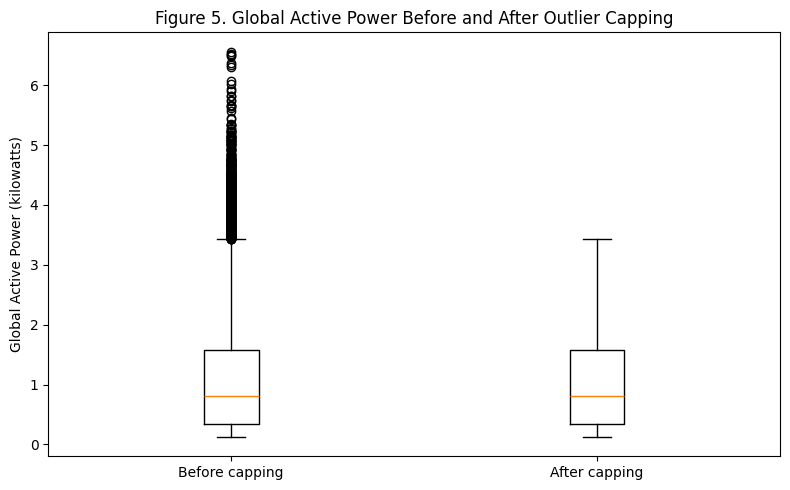

In [8]:
# I detect extreme target values using the IQR rule and cap them instead of deleting rows.

outlier_df = clean_df.copy()

target_col = "Global_active_power"

# I calculate the IQR thresholds for the target variable.
Q1 = outlier_df[target_col].quantile(0.25)
Q3 = outlier_df[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# I identify values outside the IQR range.
outlier_mask = (outlier_df[target_col] < lower_bound) | (outlier_df[target_col] > upper_bound)
outlier_count = outlier_mask.sum()
outlier_percent = (outlier_count / len(outlier_df)) * 100

print("Target variable:", target_col)
print("Q1:", round(Q1, 4))
print("Q3:", round(Q3, 4))
print("IQR:", round(IQR, 4))
print("Lower bound:", round(lower_bound, 4))
print("Upper bound:", round(upper_bound, 4))
print("Number of outliers detected:", outlier_count)
print("Outlier percentage:", round(outlier_percent, 3), "%")

# I cap extreme values instead of deleting rows because some high electricity readings may be genuine.
outlier_treated_df = outlier_df.copy()
outlier_treated_df[target_col] = outlier_treated_df[target_col].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("\nBefore capping:")
print(outlier_df[target_col].describe())

print("\nAfter capping:")
print(outlier_treated_df[target_col].describe())

# I create a compact summary table for the report.
outlier_summary = pd.DataFrame({
    "Measure": [
        "Q1",
        "Q3",
        "IQR",
        "Lower bound",
        "Upper bound",
        "Outliers detected",
        "Outlier percentage"
    ],
    "Value": [
        round(Q1, 4),
        round(Q3, 4),
        round(IQR, 4),
        round(lower_bound, 4),
        round(upper_bound, 4),
        int(outlier_count),
        round(outlier_percent, 3)
    ]
})

print("\nOutlier summary table:")
display(outlier_summary)

# Figure 5: Comparison before and after outlier capping
plt.figure(figsize=(8, 5))
plt.boxplot(
    [outlier_df[target_col], outlier_treated_df[target_col]],
    tick_labels=["Before capping", "After capping"]
)
plt.title("Figure 5. Global Active Power Before and After Outlier Capping")
plt.ylabel("Global Active Power (kilowatts)")
save_figure("figure_5_before_after_outlier_capping.png")

Smoothing window used: 24 hours

Original target summary:
count    34589.000000
mean         1.092488
std          0.895746
min          0.124000
25%          0.343433
50%          0.806833
75%          1.578233
max          6.560533
Name: Global_active_power, dtype: float64

Smoothed target summary:
count    34589.000000
mean         1.093111
std          0.427757
min          0.172947
25%          0.818771
50%          1.078751
75%          1.320975
max          4.222889
Name: Global_active_power_smoothed, dtype: float64


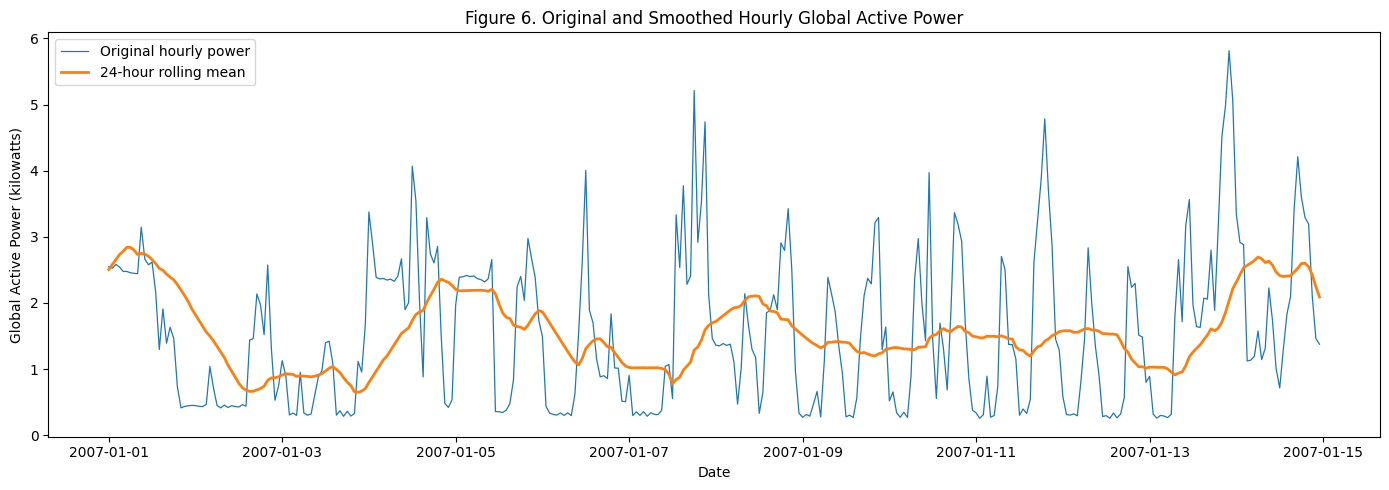


Smoothed modelling dataset shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.927544,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.751774,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.630972,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.516071,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [9]:
# I apply rolling mean smoothing to reduce short-term noise in the hourly energy series.

smoothed_df = clean_df.copy()

# I use a 24-hour rolling window because it captures one daily cycle in household electricity use.
window_size = 24

smoothed_df["Global_active_power_smoothed"] = (
    smoothed_df["Global_active_power"]
    .rolling(window=window_size, min_periods=1)
    .mean()
)

print("Smoothing window used:", window_size, "hours")

print("\nOriginal target summary:")
print(smoothed_df["Global_active_power"].describe())

print("\nSmoothed target summary:")
print(smoothed_df["Global_active_power_smoothed"].describe())

# I show a smaller period so the smoothing effect is visible.
sample_start = "2007-01-01"
sample_end = "2007-01-14"

plt.figure(figsize=(14, 5))
plt.plot(
    smoothed_df.loc[sample_start:sample_end].index,
    smoothed_df.loc[sample_start:sample_end, "Global_active_power"],
    linewidth=0.9,
    label="Original hourly power"
)
plt.plot(
    smoothed_df.loc[sample_start:sample_end].index,
    smoothed_df.loc[sample_start:sample_end, "Global_active_power_smoothed"],
    linewidth=2,
    label="24-hour rolling mean"
)

plt.title("Figure 6. Original and Smoothed Hourly Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kilowatts)")
plt.legend()
save_figure("figure_6_original_vs_smoothed_global_active_power.png")

# I create a modelling version where the target is replaced by the smoothed target.
smoothed_model_df = clean_df.copy()
smoothed_model_df["Global_active_power"] = smoothed_df["Global_active_power_smoothed"]

print("\nSmoothed modelling dataset shape:", smoothed_model_df.shape)
display(smoothed_model_df.head())

In [10]:
# create time-based and lag features so the models can learn household consumption patterns.

def create_forecasting_features(data, target="Global_active_power"):
    # I copy the data so the original version stays unchanged.
    feature_df = data.copy()
    
    # Time-based features help the model learn daily, weekly and seasonal consumption patterns.
    feature_df["hour"] = feature_df.index.hour
    feature_df["dayofweek"] = feature_df.index.dayofweek
    feature_df["month"] = feature_df.index.month
    feature_df["dayofyear"] = feature_df.index.dayofyear
    feature_df["is_weekend"] = (feature_df.index.dayofweek >= 5).astype(int)
    
    # Lag features allow the model to use recent electricity use to predict the next period.
    feature_df["lag_1_hour"] = feature_df[target].shift(1)
    feature_df["lag_24_hours"] = feature_df[target].shift(24)
    feature_df["lag_168_hours"] = feature_df[target].shift(168)
    
    # Rolling statistics capture short-term and daily behaviour.
    feature_df["rolling_mean_24h"] = feature_df[target].shift(1).rolling(window=24).mean()
    feature_df["rolling_std_24h"] = feature_df[target].shift(1).rolling(window=24).std()
    
    # I remove rows created as missing by lag and rolling calculations.
    feature_df = feature_df.dropna()
    
    return feature_df

# I create features for three versions of the dataset.
baseline_features = create_forecasting_features(clean_df)
outlier_features = create_forecasting_features(outlier_treated_df)
smoothed_features = create_forecasting_features(smoothed_model_df)

print("Baseline feature dataset shape:", baseline_features.shape)
print("Outlier-treated feature dataset shape:", outlier_features.shape)
print("Smoothed feature dataset shape:", smoothed_features.shape)

print("\nFeature columns:")
print(baseline_features.columns.tolist())

print("\nPreview of baseline feature dataset:")
display(baseline_features.head())

print("\nMissing values after feature engineering:")
print(baseline_features.isna().sum().sum())

Baseline feature dataset shape: (34421, 17)
Outlier-treated feature dataset shape: (34421, 17)
Smoothed feature dataset shape: (34421, 17)

Feature columns:
['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'lag_1_hour', 'lag_24_hours', 'lag_168_hours', 'rolling_mean_24h', 'rolling_std_24h']

Preview of baseline feature dataset:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,dayofweek,month,dayofyear,is_weekend,lag_1_hour,lag_24_hours,lag_168_hours,rolling_mean_24h,rolling_std_24h
datetime,,,,,,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,0.215967,233.644167,23.360000,16.183333,0.666667,16.750000,17,5,12,357,1,4.349100,1.496800,4.222889,2.934890,0.990187
2006-12-23 18:00:00,3.879400,0.099767,238.000500,16.363333,0.000000,0.016667,17.350000,18,5,12,357,1,5.452533,2.686967,3.632200,3.099713,1.066674
2006-12-23 19:00:00,4.117833,0.205333,238.729333,17.300000,0.000000,0.600000,17.466667,19,5,12,357,1,3.879400,3.938167,3.400233,3.149397,1.074356
2006-12-23 20:00:00,4.181400,0.124767,238.518833,17.596667,0.000000,0.350000,17.416667,20,5,12,357,1,4.117833,3.536067,3.268567,3.156883,1.080699
2006-12-23 21:00:00,3.288433,0.235767,238.594667,13.893333,0.000000,0.216667,5.666667,21,5,12,357,1,4.181400,4.548667,3.056467,3.183772,1.098426



Missing values after feature engineering:
0


In [11]:
# I split the data using time order, not random sampling, because this is a forecasting problem.

target = "Global_active_power"

# I remove Global_intensity from predictors because it is almost perfectly correlated with the target.
# Keeping it may make the model look unrealistically strong.
drop_cols = [target, "Global_intensity"]

feature_cols = [col for col in baseline_features.columns if col not in drop_cols]

print("Number of predictor features:", len(feature_cols))
print("\nPredictor features used:")
print(feature_cols)

def time_train_test_split(feature_data, target_col=target, predictors=feature_cols, train_ratio=0.8):
    # I keep the earlier 80% for training and the later 20% for testing.
    split_index = int(len(feature_data) * train_ratio)
    
    train_data = feature_data.iloc[:split_index]
    test_data = feature_data.iloc[split_index:]
    
    X_train = train_data[predictors]
    y_train = train_data[target_col]
    X_test = test_data[predictors]
    y_test = test_data[target_col]
    
    return X_train, X_test, y_train, y_test, train_data, test_data

X_train_base, X_test_base, y_train_base, y_test_base, train_base, test_base = time_train_test_split(baseline_features)
X_train_out, X_test_out, y_train_out, y_test_out, train_out, test_out = time_train_test_split(outlier_features)
X_train_smooth, X_test_smooth, y_train_smooth, y_test_smooth, train_smooth, test_smooth = time_train_test_split(smoothed_features)

print("\nBaseline split:")
print("Training period:", train_base.index.min(), "to", train_base.index.max())
print("Testing period:", test_base.index.min(), "to", test_base.index.max())
print("X_train shape:", X_train_base.shape)
print("X_test shape:", X_test_base.shape)

print("\nTarget summary in training data:")
print(y_train_base.describe())

print("\nTarget summary in testing data:")
print(y_test_base.describe())

Number of predictor features: 15

Predictor features used:
['Global_reactive_power', 'Voltage', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'lag_1_hour', 'lag_24_hours', 'lag_168_hours', 'rolling_mean_24h', 'rolling_std_24h']

Baseline split:
Training period: 2006-12-23 17:00:00 to 2010-02-13 00:00:00
Testing period: 2010-02-13 01:00:00 to 2010-11-26 21:00:00
X_train shape: (27536, 15)
X_test shape: (6885, 15)

Target summary in training data:
count    27536.000000
mean         1.111086
std          0.928713
min          0.124000
25%          0.333258
50%          0.812667
75%          1.611492
max          6.560533
Name: Global_active_power, dtype: float64

Target summary in testing data:
count    6885.000000
mean        1.001722
std         0.727319
min         0.195100
25%         0.374833
50%         0.774867
75%         1.475333
max         5.626833
Name: Global_active_power, dtype: float64


In [12]:
# I train baseline forecasting models on the cleaned hourly dataset.

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_regression_model(model_name, y_true, y_pred):
    # I calculate common regression metrics used for forecasting performance.
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

baseline_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

baseline_results = []
baseline_predictions = {}

for model_name, model in baseline_models.items():
    print("Training:", model_name)
    
    model.fit(X_train_base, y_train_base)
    predictions = model.predict(X_test_base)
    
    baseline_predictions[model_name] = predictions
    baseline_results.append(
        evaluate_regression_model(model_name, y_test_base, predictions)
    )

baseline_results_df = pd.DataFrame(baseline_results).sort_values(by="RMSE")

print("\nBaseline model performance on cleaned hourly data:")
display(baseline_results_df)

Training: Linear Regression
Training: Random Forest
Training: Gradient Boosting

Baseline model performance on cleaned hourly data:


,Model,MAE,RMSE,R2
1,Random Forest,0.159783,0.242993,0.888364
2,Gradient Boosting,0.175585,0.253968,0.878053
0,Linear Regression,0.213451,0.287546,0.843675


In [13]:
# I compare model performance across cleaned, outlier-treated and smoothed datasets.

def train_and_compare_models(dataset_name, X_train, X_test, y_train, y_test):
    results = []
    predictions_store = {}
    fitted_models_store = {}
    
    models = {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        
        "Random Forest": RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ),
        
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    }
    
    for model_name, model in models.items():
        print(f"Training {model_name} on {dataset_name} data")
        
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        row = evaluate_regression_model(model_name, y_test, predictions)
        row["Dataset Version"] = dataset_name
        
        results.append(row)
        predictions_store[model_name] = predictions
        fitted_models_store[model_name] = model
    
    return pd.DataFrame(results), predictions_store, fitted_models_store

baseline_compare_df, baseline_compare_preds, baseline_fitted_models = train_and_compare_models(
    "Cleaned baseline",
    X_train_base, X_test_base, y_train_base, y_test_base
)

outlier_compare_df, outlier_compare_preds, outlier_fitted_models = train_and_compare_models(
    "Outlier-treated",
    X_train_out, X_test_out, y_train_out, y_test_out
)

smoothed_compare_df, smoothed_compare_preds, smoothed_fitted_models = train_and_compare_models(
    "Smoothed",
    X_train_smooth, X_test_smooth, y_train_smooth, y_test_smooth
)

all_results_df = pd.concat(
    [baseline_compare_df, outlier_compare_df, smoothed_compare_df],
    ignore_index=True
)

all_results_df = all_results_df[
    ["Dataset Version", "Model", "MAE", "RMSE", "R2"]
].sort_values(by=["RMSE", "MAE"])

print("\nFull model comparison across dataset versions:")
display(all_results_df)

# I also create a pivot table to make model comparison easier for the report.
rmse_pivot = all_results_df.pivot(
    index="Model",
    columns="Dataset Version",
    values="RMSE"
)

print("\nRMSE comparison table:")
display(rmse_pivot)

Training Linear Regression on Cleaned baseline data
Training Random Forest on Cleaned baseline data
Training Gradient Boosting on Cleaned baseline data
Training Linear Regression on Outlier-treated data
Training Random Forest on Outlier-treated data
Training Gradient Boosting on Outlier-treated data
Training Linear Regression on Smoothed data
Training Random Forest on Smoothed data
Training Gradient Boosting on Smoothed data

Full model comparison across dataset versions:


,Dataset Version,Model,MAE,RMSE,R2
6,Smoothed,Linear Regression,0.018638,0.024684,0.993714
8,Smoothed,Gradient Boosting,0.018495,0.024978,0.993563
7,Smoothed,Random Forest,0.018629,0.025261,0.993416
4,Outlier-treated,Random Forest,0.158202,0.239670,0.887574
1,Cleaned baseline,Random Forest,0.159783,0.242993,0.888364
5,Outlier-treated,Gradient Boosting,0.172153,0.247767,0.879850
2,Cleaned baseline,Gradient Boosting,0.175585,0.253968,0.878053
3,Outlier-treated,Linear Regression,0.212353,0.284906,0.841130
0,Cleaned baseline,Linear Regression,0.213451,0.287546,0.843675



RMSE comparison table:


Dataset Version,Cleaned baseline,Outlier-treated,Smoothed
Model,,,
Gradient Boosting,0.253968,0.247767,0.024978
Linear Regression,0.287546,0.284906,0.024684
Random Forest,0.242993,0.239670,0.025261


In [14]:
# I combine outlier capping and smoothing to test the full preprocessing pipeline.

combined_df = outlier_treated_df.copy()

# I smooth the capped target using the same 24-hour rolling mean.
combined_df["Global_active_power"] = (
    combined_df["Global_active_power"]
    .rolling(window=24, min_periods=1)
    .mean()
)

# I create the same forecasting features for the combined dataset.
combined_features = create_forecasting_features(combined_df)

print("Combined preprocessed feature dataset shape:", combined_features.shape)

# I split the combined dataset using the same time-based split.
X_train_combined, X_test_combined, y_train_combined, y_test_combined, train_combined, test_combined = time_train_test_split(
    combined_features
)

print("\nCombined split:")
print("Training period:", train_combined.index.min(), "to", train_combined.index.max())
print("Testing period:", test_combined.index.min(), "to", test_combined.index.max())
print("X_train shape:", X_train_combined.shape)
print("X_test shape:", X_test_combined.shape)

# I train the same models on the combined preprocessing version.
combined_compare_df, combined_compare_preds, combined_fitted_models = train_and_compare_models(
    "Outlier-treated + Smoothed",
    X_train_combined, X_test_combined, y_train_combined, y_test_combined
)

# I combine all previous results with the combined preprocessing results.
final_results_df = pd.concat(
    [all_results_df, combined_compare_df],
    ignore_index=True
)

final_results_df = final_results_df[
    ["Dataset Version", "Model", "MAE", "RMSE", "R2"]
].sort_values(by=["RMSE", "MAE"])

print("\nFinal model comparison including combined preprocessing:")
display(final_results_df)

# I create a final RMSE table for the report.
final_rmse_pivot = final_results_df.pivot(
    index="Model",
    columns="Dataset Version",
    values="RMSE"
)

print("\nFinal RMSE comparison table:")
display(final_rmse_pivot)

# I calculate improvement compared with the best cleaned baseline model.
baseline_best_rmse = all_results_df[
    all_results_df["Dataset Version"] == "Cleaned baseline"
]["RMSE"].min()

best_final_row = final_results_df.iloc[0]
best_final_rmse = best_final_row["RMSE"]

rmse_reduction = ((baseline_best_rmse - best_final_rmse) / baseline_best_rmse) * 100

print("\nBest cleaned baseline RMSE:", round(baseline_best_rmse, 6))
print("Best final RMSE:", round(best_final_rmse, 6))
print("Best final model:", best_final_row["Model"])
print("Best final dataset version:", best_final_row["Dataset Version"])
print("RMSE reduction compared with cleaned baseline:", round(rmse_reduction, 2), "%")

Combined preprocessed feature dataset shape: (34421, 17)

Combined split:
Training period: 2006-12-23 17:00:00 to 2010-02-13 00:00:00
Testing period: 2010-02-13 01:00:00 to 2010-11-26 21:00:00
X_train shape: (27536, 15)
X_test shape: (6885, 15)
Training Linear Regression on Outlier-treated + Smoothed data
Training Random Forest on Outlier-treated + Smoothed data
Training Gradient Boosting on Outlier-treated + Smoothed data

Final model comparison including combined preprocessing:


,Dataset Version,Model,MAE,RMSE,R2
9,Outlier-treated + Smoothed,Linear Regression,0.018370,0.024141,0.993782
11,Outlier-treated + Smoothed,Gradient Boosting,0.018239,0.024356,0.993670
0,Smoothed,Linear Regression,0.018638,0.024684,0.993714
10,Outlier-treated + Smoothed,Random Forest,0.018632,0.024878,0.993396
1,Smoothed,Gradient Boosting,0.018495,0.024978,0.993563
2,Smoothed,Random Forest,0.018629,0.025261,0.993416
3,Outlier-treated,Random Forest,0.158202,0.239670,0.887574
4,Cleaned baseline,Random Forest,0.159783,0.242993,0.888364
5,Outlier-treated,Gradient Boosting,0.172153,0.247767,0.879850
6,Cleaned baseline,Gradient Boosting,0.175585,0.253968,0.878053



Final RMSE comparison table:


Dataset Version,Cleaned baseline,Outlier-treated,Outlier-treated + Smoothed,Smoothed
Model,,,,
Gradient Boosting,0.253968,0.247767,0.024356,0.024978
Linear Regression,0.287546,0.284906,0.024141,0.024684
Random Forest,0.242993,0.239670,0.024878,0.025261



Best cleaned baseline RMSE: 0.242993
Best final RMSE: 0.024141
Best final model: Linear Regression
Best final dataset version: Outlier-treated + Smoothed
RMSE reduction compared with cleaned baseline: 90.07 %


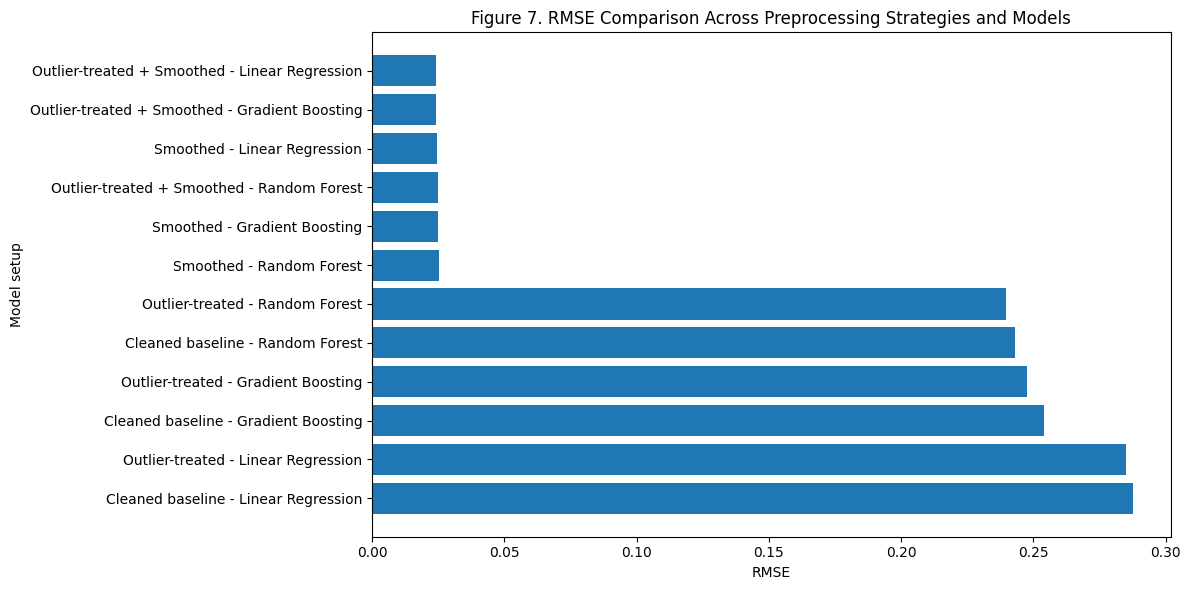

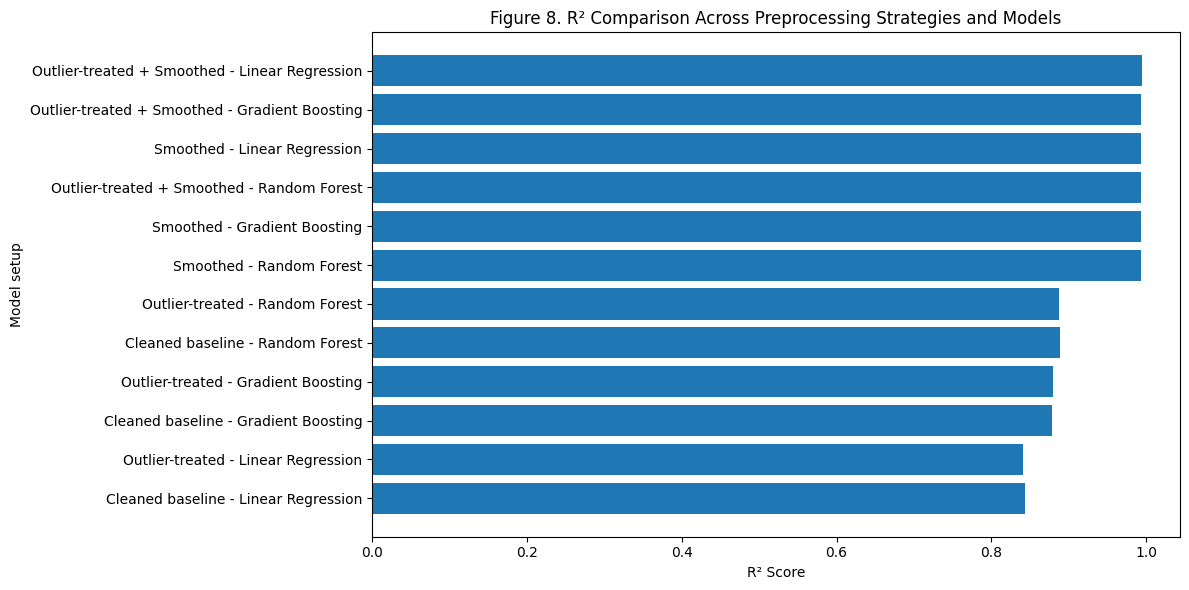

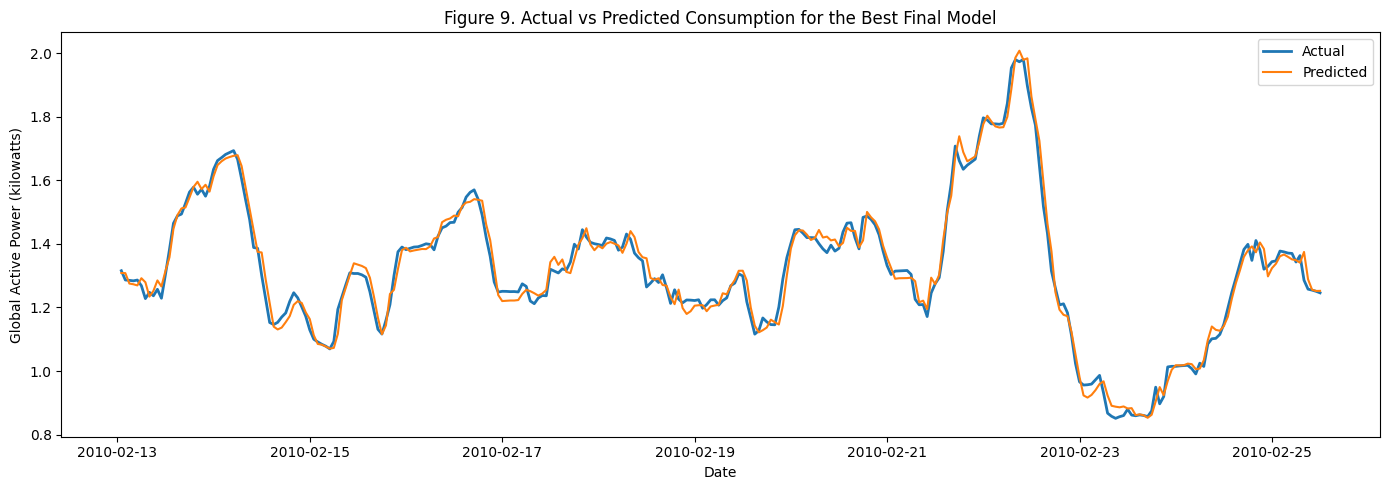

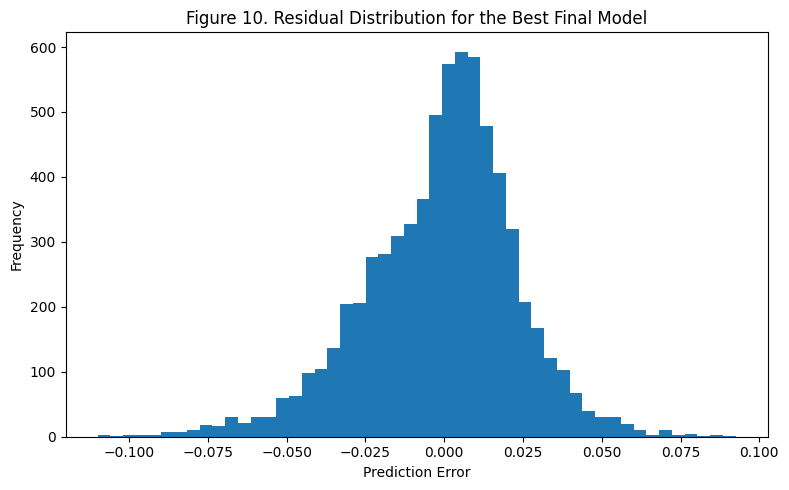

Best model used for Figures 9 and 10: Linear Regression
Best dataset version: Outlier-treated + Smoothed
Figures saved in: energy_forecasting_figures


In [15]:
# I create model comparison figures for the Results and Discussion section.

# Figure 7: RMSE comparison across all dataset versions and models
plot_results = final_results_df.copy()
plot_results["Model setup"] = plot_results["Dataset Version"] + " - " + plot_results["Model"]

plt.figure(figsize=(12, 6))
plt.barh(plot_results["Model setup"], plot_results["RMSE"])
plt.xlabel("RMSE")
plt.ylabel("Model setup")
plt.title("Figure 7. RMSE Comparison Across Preprocessing Strategies and Models")
plt.gca().invert_yaxis()
save_figure("figure_7_rmse_comparison_models_preprocessing.png")

# Figure 8: R2 comparison across all dataset versions and models
plt.figure(figsize=(12, 6))
plt.barh(plot_results["Model setup"], plot_results["R2"])
plt.xlabel("R² Score")
plt.ylabel("Model setup")
plt.title("Figure 8. R² Comparison Across Preprocessing Strategies and Models")
plt.gca().invert_yaxis()
save_figure("figure_8_r2_comparison_models_preprocessing.png")

# Figure 9: Actual vs predicted values for the best final model
best_model_name = best_final_row["Model"]
best_dataset_version = best_final_row["Dataset Version"]

if best_dataset_version == "Outlier-treated + Smoothed":
    best_predictions = combined_compare_preds[best_model_name]
    best_y_test = y_test_combined
elif best_dataset_version == "Smoothed":
    best_predictions = smoothed_compare_preds[best_model_name]
    best_y_test = y_test_smooth
elif best_dataset_version == "Outlier-treated":
    best_predictions = outlier_compare_preds[best_model_name]
    best_y_test = y_test_out
else:
    best_predictions = baseline_compare_preds[best_model_name]
    best_y_test = y_test_base

plt.figure(figsize=(14, 5))
plt.plot(best_y_test.index[:300], best_y_test.iloc[:300], label="Actual", linewidth=2)
plt.plot(best_y_test.index[:300], best_predictions[:300], label="Predicted", linewidth=1.5)
plt.title("Figure 9. Actual vs Predicted Consumption for the Best Final Model")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kilowatts)")
plt.legend()
save_figure("figure_9_actual_vs_predicted_best_final_model.png")

# Figure 10: Residual distribution for the best final model
best_residuals = best_y_test.values - best_predictions

plt.figure(figsize=(8, 5))
plt.hist(best_residuals, bins=50)
plt.title("Figure 10. Residual Distribution for the Best Final Model")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
save_figure("figure_10_residual_distribution_best_final_model.png")

print("Best model used for Figures 9 and 10:", best_model_name)
print("Best dataset version:", best_dataset_version)
print("Figures saved in:", fig_dir)

Best raw-demand model: Random Forest
Dataset version: Outlier-treated

Random Forest feature importance table:


,Feature,Importance
4,Sub_metering_3,0.511573
10,lag_1_hour,0.183565
3,Sub_metering_2,0.075882
2,Sub_metering_1,0.074974
5,hour,0.037143
1,Voltage,0.030659
13,rolling_mean_24h,0.016632
11,lag_24_hours,0.016150
12,lag_168_hours,0.015476
8,dayofyear,0.013454


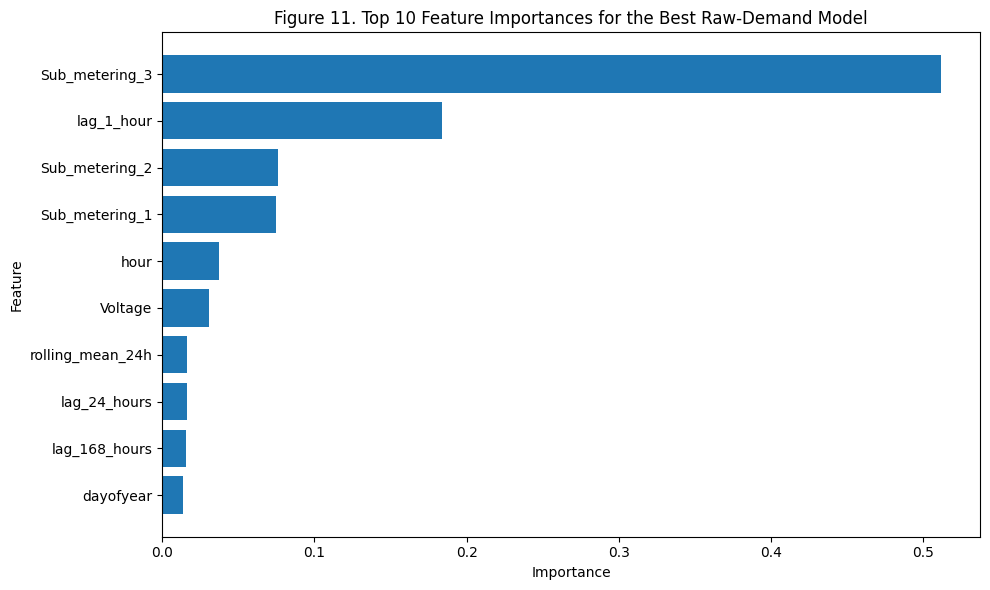


Best final model: Linear Regression
Dataset version: Outlier-treated + Smoothed

Linear regression coefficient table:


,Feature,Coefficient,Absolute coefficient
10,lag_1_hour,0.447110,0.447110
13,rolling_mean_24h,-0.051462,0.051462
11,lag_24_hours,0.019132,0.019132
4,Sub_metering_3,0.013718,0.013718
3,Sub_metering_2,0.009631,0.009631
2,Sub_metering_1,0.008202,0.008202
5,hour,-0.004713,0.004713
14,rolling_std_24h,0.001950,0.001950
0,Global_reactive_power,0.001737,0.001737
12,lag_168_hours,0.001631,0.001631


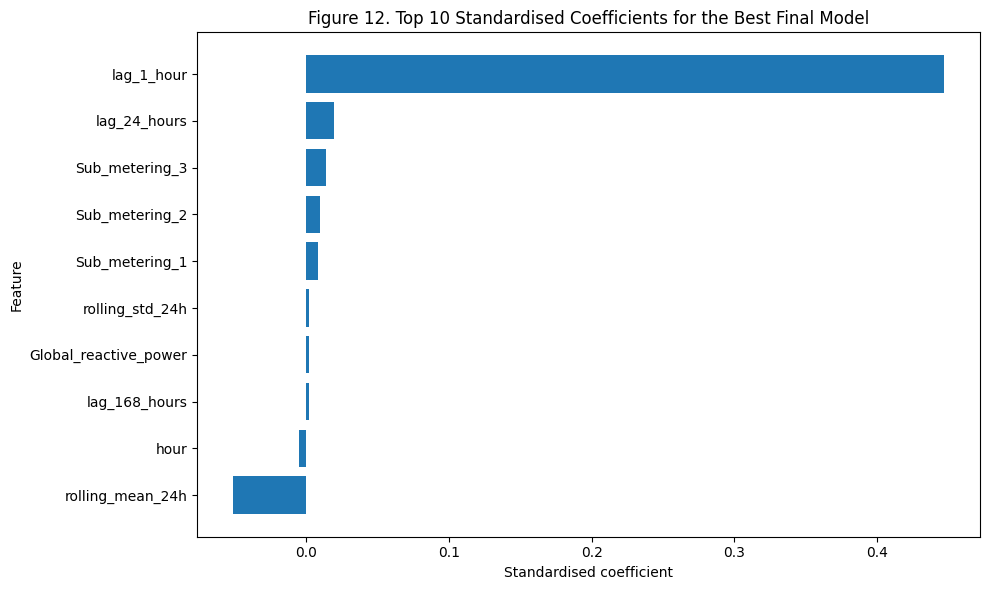


Feature importance tables saved:
- rf_feature_importance_table.csv
- linear_regression_coefficients_table.csv


In [16]:
# I analyse feature importance for both the best raw-demand model and the best final model.

# Part A: Feature importance for the best raw-demand model

# I use the best non-smoothed model because it reflects raw hourly forecasting more realistically.
best_raw_model_name = "Random Forest"
best_raw_dataset_version = "Outlier-treated"

best_raw_model = outlier_fitted_models[best_raw_model_name]

rf_importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": best_raw_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Best raw-demand model:", best_raw_model_name)
print("Dataset version:", best_raw_dataset_version)
print("\nRandom Forest feature importance table:")
display(rf_importance_df)

# Figure 11: Top feature importances for the best raw-demand model
top_n = 10
rf_top = rf_importance_df.head(top_n).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(rf_top["Feature"], rf_top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Figure 11. Top 10 Feature Importances for the Best Raw-Demand Model")
save_figure("figure_11_top_feature_importances_raw_model.png")


# Part B: Coefficient importance for the best final model

# I use the final best model from the combined preprocessing pipeline.
best_final_model_pipeline = combined_fitted_models["Linear Regression"]

# I extract the fitted linear regression model from the pipeline.
linear_model = best_final_model_pipeline.named_steps["model"]

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": linear_model.coef_
})

coef_df["Absolute coefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values(by="Absolute coefficient", ascending=False)

print("\nBest final model: Linear Regression")
print("Dataset version: Outlier-treated + Smoothed")
print("\nLinear regression coefficient table:")
display(coef_df)

# Figure 12: Top standardised coefficients for the best final model
coef_top = coef_df.head(top_n).sort_values(by="Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(coef_top["Feature"], coef_top["Coefficient"])
plt.xlabel("Standardised coefficient")
plt.ylabel("Feature")
plt.title("Figure 12. Top 10 Standardised Coefficients for the Best Final Model")
save_figure("figure_12_top_coefficients_best_final_model.png")

# I also save the two tables for later reporting if needed.
rf_importance_df.to_csv("rf_feature_importance_table.csv", index=False)
coef_df.to_csv("linear_regression_coefficients_table.csv", index=False)

print("\nFeature importance tables saved:")
print("- rf_feature_importance_table.csv")
print("- linear_regression_coefficients_table.csv")

In [19]:
# I now run a stricter forecasting-safe model using only calendar, lag and rolling features.
# I do this because same-hour electrical variables may not be available in a real future forecast.

safe_feature_cols = [
    "hour",
    "dayofweek",
    "month",
    "dayofyear",
    "is_weekend",
    "lag_1_hour",
    "lag_24_hours",
    "lag_168_hours",
    "rolling_mean_24h",
    "rolling_std_24h"
]

print("Forecasting-safe features used:")
print(safe_feature_cols)


def time_train_test_split_safe(feature_data, target_col="Global_active_power", predictors=safe_feature_cols, train_ratio=0.8):
    # I keep the time order to avoid future information leaking into training.
    split_index = int(len(feature_data) * train_ratio)
    
    train_data = feature_data.iloc[:split_index]
    test_data = feature_data.iloc[split_index:]
    
    X_train = train_data[predictors]
    y_train = train_data[target_col]
    X_test = test_data[predictors]
    y_test = test_data[target_col]
    
    return X_train, X_test, y_train, y_test, train_data, test_data


# I create forecasting-safe splits for all dataset versions.
X_train_base_safe, X_test_base_safe, y_train_base_safe, y_test_base_safe, train_base_safe, test_base_safe = time_train_test_split_safe(baseline_features)

X_train_out_safe, X_test_out_safe, y_train_out_safe, y_test_out_safe, train_out_safe, test_out_safe = time_train_test_split_safe(outlier_features)

X_train_smooth_safe, X_test_smooth_safe, y_train_smooth_safe, y_test_smooth_safe, train_smooth_safe, test_smooth_safe = time_train_test_split_safe(smoothed_features)

X_train_combined_safe, X_test_combined_safe, y_train_combined_safe, y_test_combined_safe, train_combined_safe, test_combined_safe = time_train_test_split_safe(combined_features)


print("\nSafe split check:")
print("Training period:", train_base_safe.index.min(), "to", train_base_safe.index.max())
print("Testing period:", test_base_safe.index.min(), "to", test_base_safe.index.max())
print("X_train shape:", X_train_base_safe.shape)
print("X_test shape:", X_test_base_safe.shape)


def train_and_compare_safe_models(dataset_name, X_train, X_test, y_train, y_test):
    results = []
    predictions_store = {}
    fitted_models_store = {}
    
    models = {
        "Linear Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),
        
        "Random Forest": RandomForestRegressor(
            n_estimators=120,
            max_depth=18,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        ),
        
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )
    }
    
    for model_name, model in models.items():
        print(f"Training {model_name} on {dataset_name} forecasting-safe data")
        
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        
        row = evaluate_regression_model(model_name, y_test, predictions)
        row["Dataset Version"] = dataset_name
        row["Feature Set"] = "Forecasting-safe"
        
        results.append(row)
        predictions_store[model_name] = predictions
        fitted_models_store[model_name] = model
    
    return pd.DataFrame(results), predictions_store, fitted_models_store


safe_baseline_df, safe_baseline_preds, safe_baseline_models = train_and_compare_safe_models(
    "Cleaned baseline",
    X_train_base_safe, X_test_base_safe, y_train_base_safe, y_test_base_safe
)

safe_outlier_df, safe_outlier_preds, safe_outlier_models = train_and_compare_safe_models(
    "Outlier-treated",
    X_train_out_safe, X_test_out_safe, y_train_out_safe, y_test_out_safe
)

safe_smoothed_df, safe_smoothed_preds, safe_smoothed_models = train_and_compare_safe_models(
    "Smoothed",
    X_train_smooth_safe, X_test_smooth_safe, y_train_smooth_safe, y_test_smooth_safe
)

safe_combined_df, safe_combined_preds, safe_combined_models = train_and_compare_safe_models(
    "Outlier-treated + Smoothed",
    X_train_combined_safe, X_test_combined_safe, y_train_combined_safe, y_test_combined_safe
)


safe_results_df = pd.concat(
    [safe_baseline_df, safe_outlier_df, safe_smoothed_df, safe_combined_df],
    ignore_index=True
)

safe_results_df = safe_results_df[
    ["Feature Set", "Dataset Version", "Model", "MAE", "RMSE", "R2"]
].sort_values(by=["RMSE", "MAE"])


print("\nForecasting-safe model comparison:")
display(safe_results_df)


safe_rmse_pivot = safe_results_df.pivot(
    index="Model",
    columns="Dataset Version",
    values="RMSE"
)

print("\nForecasting-safe RMSE comparison table:")
display(safe_rmse_pivot)


# I calculate the improvement from the best safe cleaned baseline to the best safe final model.
safe_baseline_best_rmse = safe_results_df[
    safe_results_df["Dataset Version"] == "Cleaned baseline"
]["RMSE"].min()

safe_best_row = safe_results_df.iloc[0]
safe_best_rmse = safe_best_row["RMSE"]

safe_rmse_reduction = ((safe_baseline_best_rmse - safe_best_rmse) / safe_baseline_best_rmse) * 100


print("\nBest safe cleaned baseline RMSE:", round(safe_baseline_best_rmse, 6))
print("Best safe final RMSE:", round(safe_best_rmse, 6))
print("Best safe final model:", safe_best_row["Model"])
print("Best safe final dataset version:", safe_best_row["Dataset Version"])
print("Safe RMSE reduction compared with cleaned baseline:", round(safe_rmse_reduction, 2), "%")

Forecasting-safe features used:
['hour', 'dayofweek', 'month', 'dayofyear', 'is_weekend', 'lag_1_hour', 'lag_24_hours', 'lag_168_hours', 'rolling_mean_24h', 'rolling_std_24h']

Safe split check:
Training period: 2006-12-23 17:00:00 to 2010-02-13 00:00:00
Testing period: 2010-02-13 01:00:00 to 2010-11-26 21:00:00
X_train shape: (27536, 10)
X_test shape: (6885, 10)
Training Linear Regression on Cleaned baseline forecasting-safe data
Training Random Forest on Cleaned baseline forecasting-safe data
Training Gradient Boosting on Cleaned baseline forecasting-safe data
Training Linear Regression on Outlier-treated forecasting-safe data
Training Random Forest on Outlier-treated forecasting-safe data
Training Gradient Boosting on Outlier-treated forecasting-safe data
Training Linear Regression on Smoothed forecasting-safe data
Training Random Forest on Smoothed forecasting-safe data
Training Gradient Boosting on Smoothed forecasting-safe data
Training Linear Regression on Outlier-treated + Smoo

,Feature Set,Dataset Version,Model,MAE,RMSE,R2
9,Forecasting-safe,Outlier-treated + Smoothed,Linear Regression,0.021395,0.029499,0.990715
6,Forecasting-safe,Smoothed,Linear Regression,0.021690,0.030270,0.990547
11,Forecasting-safe,Outlier-treated + Smoothed,Gradient Boosting,0.021585,0.030381,0.990151
10,Forecasting-safe,Outlier-treated + Smoothed,Random Forest,0.022629,0.030936,0.989788
8,Forecasting-safe,Smoothed,Gradient Boosting,0.021879,0.031182,0.989969
7,Forecasting-safe,Smoothed,Random Forest,0.022813,0.031626,0.989680
4,Forecasting-safe,Outlier-treated,Random Forest,0.324495,0.466446,0.574165
5,Forecasting-safe,Outlier-treated,Gradient Boosting,0.332340,0.467417,0.572390
1,Forecasting-safe,Cleaned baseline,Random Forest,0.329841,0.479921,0.564535
2,Forecasting-safe,Cleaned baseline,Gradient Boosting,0.336809,0.480570,0.563357



Forecasting-safe RMSE comparison table:


Dataset Version,Cleaned baseline,Outlier-treated,Outlier-treated + Smoothed,Smoothed
Model,,,,
Gradient Boosting,0.480570,0.467417,0.030381,0.031182
Linear Regression,0.511732,0.499098,0.029499,0.030270
Random Forest,0.479921,0.466446,0.030936,0.031626



Best safe cleaned baseline RMSE: 0.479921
Best safe final RMSE: 0.029499
Best safe final model: Linear Regression
Best safe final dataset version: Outlier-treated + Smoothed
Safe RMSE reduction compared with cleaned baseline: 93.85 %


Best forecasting-safe model: Linear Regression
Best forecasting-safe dataset version: Outlier-treated + Smoothed


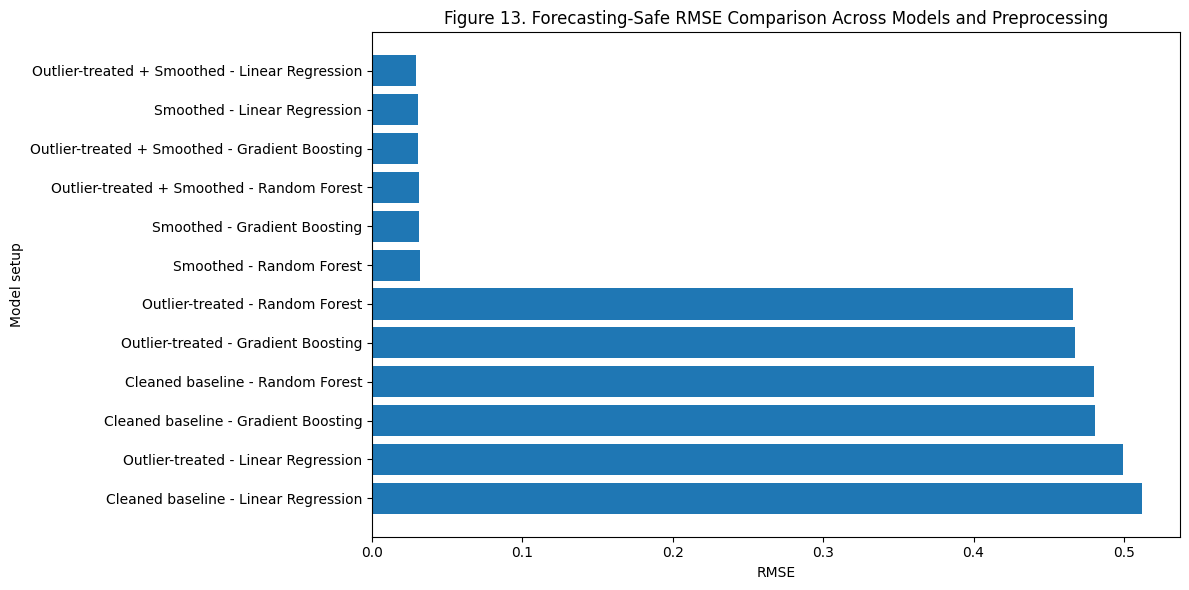

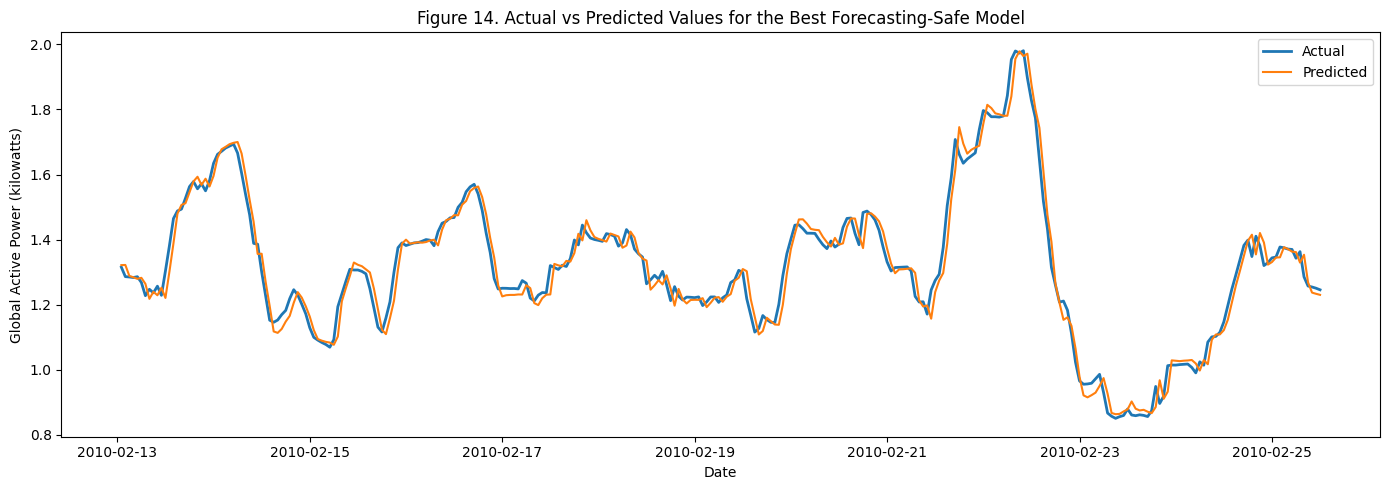

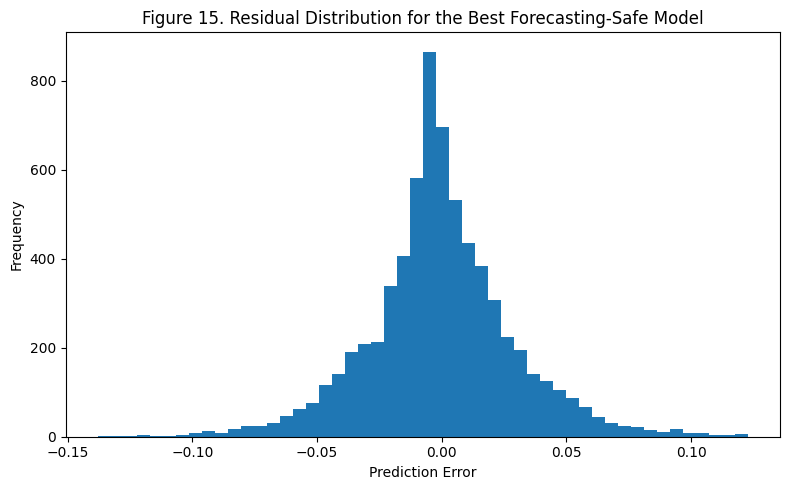

Final forecasting-safe figures saved in: energy_forecasting_figures


In [20]:
# I create final figures using the forecasting-safe best model because this is the most defensible result.

# I select the best forecasting-safe model.
safe_best_model_name = safe_best_row["Model"]
safe_best_dataset_version = safe_best_row["Dataset Version"]

print("Best forecasting-safe model:", safe_best_model_name)
print("Best forecasting-safe dataset version:", safe_best_dataset_version)

# I select the correct predictions and test target for the best safe result.
if safe_best_dataset_version == "Outlier-treated + Smoothed":
    safe_best_predictions = safe_combined_preds[safe_best_model_name]
    safe_best_y_test = y_test_combined_safe
elif safe_best_dataset_version == "Smoothed":
    safe_best_predictions = safe_smoothed_preds[safe_best_model_name]
    safe_best_y_test = y_test_smooth_safe
elif safe_best_dataset_version == "Outlier-treated":
    safe_best_predictions = safe_outlier_preds[safe_best_model_name]
    safe_best_y_test = y_test_out_safe
else:
    safe_best_predictions = safe_baseline_preds[safe_best_model_name]
    safe_best_y_test = y_test_base_safe

# Figure 13: Forecasting-safe RMSE comparison
safe_plot_results = safe_results_df.copy()
safe_plot_results["Model setup"] = safe_plot_results["Dataset Version"] + " - " + safe_plot_results["Model"]

plt.figure(figsize=(12, 6))
plt.barh(safe_plot_results["Model setup"], safe_plot_results["RMSE"])
plt.xlabel("RMSE")
plt.ylabel("Model setup")
plt.title("Figure 13. Forecasting-Safe RMSE Comparison Across Models and Preprocessing")
plt.gca().invert_yaxis()
save_figure("figure_13_forecasting_safe_rmse_comparison.png")

# Figure 14: Actual vs predicted for the best forecasting-safe model
plt.figure(figsize=(14, 5))
plt.plot(
    safe_best_y_test.index[:300],
    safe_best_y_test.iloc[:300],
    label="Actual",
    linewidth=2
)
plt.plot(
    safe_best_y_test.index[:300],
    safe_best_predictions[:300],
    label="Predicted",
    linewidth=1.5
)
plt.title("Figure 14. Actual vs Predicted Values for the Best Forecasting-Safe Model")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kilowatts)")
plt.legend()
save_figure("figure_14_actual_vs_predicted_forecasting_safe_model.png")

# Figure 15: Residual distribution for the best forecasting-safe model
safe_residuals = safe_best_y_test.values - safe_best_predictions

plt.figure(figsize=(8, 5))
plt.hist(safe_residuals, bins=50)
plt.title("Figure 15. Residual Distribution for the Best Forecasting-Safe Model")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
save_figure("figure_15_residual_distribution_forecasting_safe_model.png")

print("Final forecasting-safe figures saved in:", fig_dir)

In [21]:
# I export the final tables so they can be used directly in the report and appendix.

# Final model comparison tables
final_results_df.to_csv("full_feature_model_results.csv", index=False)
safe_results_df.to_csv("forecasting_safe_model_results.csv", index=False)

# RMSE pivot tables
final_rmse_pivot.to_csv("full_feature_rmse_comparison.csv")
safe_rmse_pivot.to_csv("forecasting_safe_rmse_comparison.csv")

# Preprocessing and outlier summary tables
missing_summary.to_csv("missing_value_summary.csv")
outlier_summary.to_csv("outlier_summary.csv", index=False)

# Feature importance tables from Chunk 15
rf_importance_df.to_csv("random_forest_feature_importance.csv", index=False)
coef_df.to_csv("linear_regression_coefficients.csv", index=False)

# I create one compact final summary table for the main report.
final_key_results = pd.DataFrame({
    "Experiment": [
        "Best cleaned baseline model",
        "Best outlier-treated model",
        "Best smoothed model",
        "Best outlier-treated + smoothed model"
    ],
    "Feature set": [
        "Forecasting-safe",
        "Forecasting-safe",
        "Forecasting-safe",
        "Forecasting-safe"
    ],
    "Best model": [
        safe_results_df[safe_results_df["Dataset Version"] == "Cleaned baseline"].iloc[0]["Model"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated"].iloc[0]["Model"],
        safe_results_df[safe_results_df["Dataset Version"] == "Smoothed"].iloc[0]["Model"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated + Smoothed"].iloc[0]["Model"]
    ],
    "MAE": [
        safe_results_df[safe_results_df["Dataset Version"] == "Cleaned baseline"].iloc[0]["MAE"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated"].iloc[0]["MAE"],
        safe_results_df[safe_results_df["Dataset Version"] == "Smoothed"].iloc[0]["MAE"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated + Smoothed"].iloc[0]["MAE"]
    ],
    "RMSE": [
        safe_results_df[safe_results_df["Dataset Version"] == "Cleaned baseline"].iloc[0]["RMSE"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated"].iloc[0]["RMSE"],
        safe_results_df[safe_results_df["Dataset Version"] == "Smoothed"].iloc[0]["RMSE"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated + Smoothed"].iloc[0]["RMSE"]
    ],
    "R2": [
        safe_results_df[safe_results_df["Dataset Version"] == "Cleaned baseline"].iloc[0]["R2"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated"].iloc[0]["R2"],
        safe_results_df[safe_results_df["Dataset Version"] == "Smoothed"].iloc[0]["R2"],
        safe_results_df[safe_results_df["Dataset Version"] == "Outlier-treated + Smoothed"].iloc[0]["R2"]
    ]
})

final_key_results.to_csv("final_key_results_summary.csv", index=False)

print("Export completed. Files created:")
export_files = [
    "full_feature_model_results.csv",
    "forecasting_safe_model_results.csv",
    "full_feature_rmse_comparison.csv",
    "forecasting_safe_rmse_comparison.csv",
    "missing_value_summary.csv",
    "outlier_summary.csv",
    "random_forest_feature_importance.csv",
    "linear_regression_coefficients.csv",
    "final_key_results_summary.csv"
]

for file in export_files:
    print("-", file)

print("\nFinal key results summary:")
display(final_key_results)

Export completed. Files created:
- full_feature_model_results.csv
- forecasting_safe_model_results.csv
- full_feature_rmse_comparison.csv
- forecasting_safe_rmse_comparison.csv
- missing_value_summary.csv
- outlier_summary.csv
- random_forest_feature_importance.csv
- linear_regression_coefficients.csv
- final_key_results_summary.csv

Final key results summary:


,Experiment,Feature set,Best model,MAE,RMSE,R2
0,Best cleaned baseline model,Forecasting-safe,Random Forest,0.329841,0.479921,0.564535
1,Best outlier-treated model,Forecasting-safe,Random Forest,0.324495,0.466446,0.574165
2,Best smoothed model,Forecasting-safe,Linear Regression,0.021690,0.030270,0.990547
3,Best outlier-treated + smoothed model,Forecasting-safe,Linear Regression,0.021395,0.029499,0.990715
